GPU is available
Using device: NVIDIA GeForce RTX 3090

Defect-free data is NOT included in the training data.

Dataset Sizes:
Training data size:       1296 samples
Validation data size:     162 samples
Test data size:           163 samples

Detailed Data Sizes:
Training Data size:       4735584 (Expected: 1296 * 3654 = 4735584)
Training Edge size:       7124
Training Label size:      4735584 (Expected: 1296 * 3654 = 4735584)

Validation Data size:     591948 (Expected: 162 * 3654 = 591948)
Validation Edge size:     7124
Validation Label size:    591948 (Expected: 162 * 3654 = 591948)

Test Data size:           595602 (Expected: 163 * 3654 = 595602)
Test Edge size:           7124
Test Label size:          595602 (Expected: 163 * 3654 = 595602)

Defect-free data is NOT included in the training data.

--- Training Data Sample ---
Sample 1: data: Standardized1_Defect4x4_ELNOD_L13B70.npy, label: DefectLabel_L13B70.npy
Sample 2: data: Standardized1_Defect4x4_ELNOD_L8B85.npy, label: DefectL

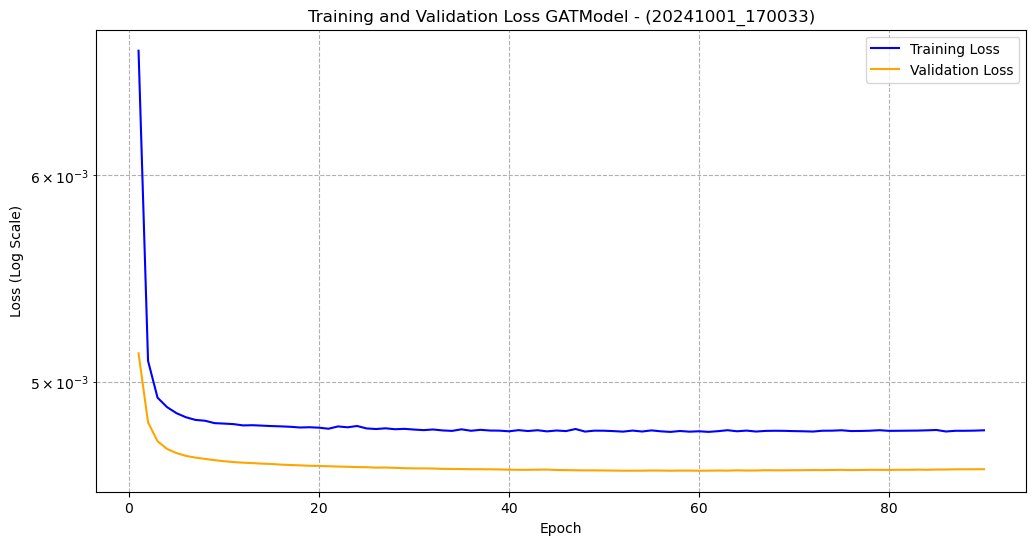

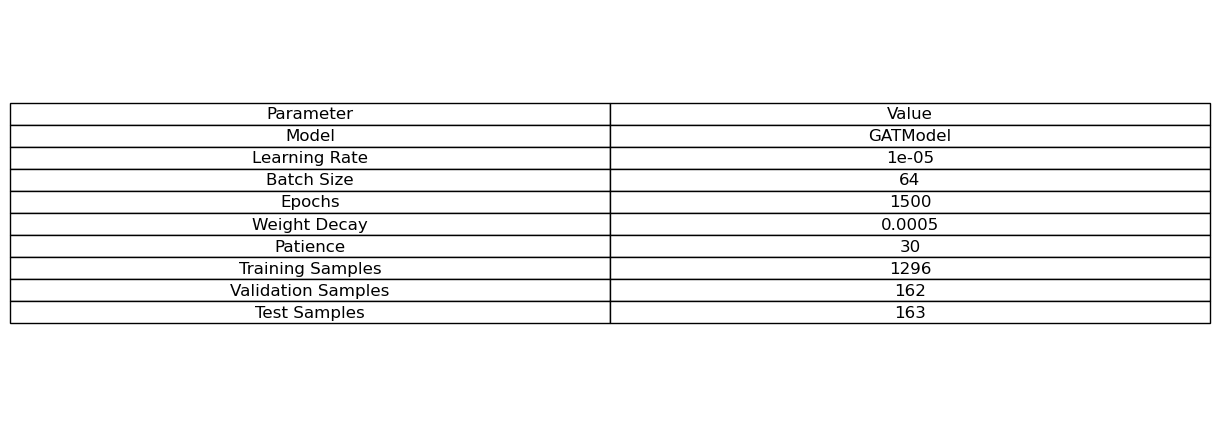

ValueError: All arrays must be of the same length

In [6]:
import os
import time
import json
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv  # 変更
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from torch.utils.tensorboard import SummaryWriter

if torch.cuda.is_available():
    print("GPU is available")
    print(f"Using device: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available, using CPU")
    
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")


# データフォルダ
standardized_data_folder = "/home/nishioka/GNN/Defect_4x4_Standardized1"
label_data_folder = "/home/nishioka/GNN/DefectLabels_4x4_test1"

# 座標データのロード
x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]

# エッジ情報を読み込む
edges = np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy")
edge_index = torch.tensor(edges.T, dtype=torch.long).to(device)

# データとラベルファイルを対応付け
data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Standardized1_Defect4x4_ELNOD")]
label_files = [f for f in os.listdir(label_data_folder) if f.startswith("DefectLabel_L")]

# 欠陥なしのファイルを追加
data_files.append("0Standardized1_nodefect_4x4_ElNOD.npy")
label_files.append("0DefectLabel_nodefect1.npy")

no_defect_in_train = ("0Standardized1_nodefect_4x4_ElNOD.npy", "0DefectLabel_nodefect1.npy") in train_pairs

# Check if defect-free data is included in the training data
if no_defect_in_train:
    print("\nDefect-free data is included in the training data.")
else:
    print("\nDefect-free data is NOT included in the training data.")

# データとラベルのペアを取得する関数
def extract_layer_block(file_name):
    if file_name.startswith("0"):
        return (0, 0)  # 欠陥なしデータの場合
    try:
        layer_block_str = file_name.split("_")[-1].replace(".npy", "")
        layer_str = layer_block_str.split("L")[1].split("B")[0]
        block_str = layer_block_str.split("B")[1]
        layer = int(layer_str)
        block = int(block_str)
        return (layer, block)
    except (ValueError, IndexError):
        print(f"無効なファイル名の形式: {file_name}")
        return None

# データとラベルのペアを作成
data_label_pairs = {}
for data_file in data_files:
    layer_block = extract_layer_block(data_file)
    if layer_block:
        data_label_pairs[layer_block] = {"data": data_file}

for label_file in label_files:
    layer_block = extract_layer_block(label_file)
    if layer_block and layer_block in data_label_pairs:
        data_label_pairs[layer_block]["label"] = label_file

# 有効なペアのみ取得
valid_pairs = [(v["data"], v["label"]) for k, v in data_label_pairs.items() if "label" in v]

# ランダムにサンプリング
num_samples = 1296
random_indices = np.random.choice(len(valid_pairs), num_samples, replace=False)

# サンプルをトレーニングデータとして取得
train_pairs = [valid_pairs[i] for i in random_indices]

# 残りのデータを取得
remaining_pairs = [valid_pairs[i] for i in range(len(valid_pairs)) if i not in random_indices]

# 残りのデータを1:1でバリデーションとテストに分割
val_pairs, test_pairs = train_test_split(remaining_pairs, test_size=0.5, random_state=42)

# 検証データとテストデータを適切に分けて格納
train_data = [pair[0] for pair in train_pairs]
train_labels = [pair[1] for pair in train_pairs]

val_data = [pair[0] for pair in val_pairs]
val_labels = [pair[1] for pair in val_pairs]

test_data = [pair[0] for pair in test_pairs]
test_labels = [pair[1] for pair in test_pairs]

# データ準備の関数
def prepare_data(pairs):
    sampled_data = []
    sampled_labels = []
    
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        # データとラベルを読み込む
        values = np.load(data_file_path)[:3654]
        label = np.load(label_file_path)[:3654]
        
        # 座標データと応力データを結合してノード特徴量を作成
        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        sampled_data.append(node_features)
        sampled_labels.append(label)
    
    # データを結合しテンソルに変換
    sampled_data = np.stack(sampled_data)
    sampled_labels = np.hstack(sampled_labels)

    x = torch.tensor(sampled_data.reshape(-1, 4), dtype=torch.float).to(device)
    y = torch.tensor(sampled_labels, dtype=torch.float).to(device)

    return x, y

# 各データセットを準備
train_x, train_y = prepare_data(train_pairs)
val_x, val_y = prepare_data(val_pairs)
test_x, test_y = prepare_data(test_pairs)

# Dataオブジェクトにまとめる
train_data = Data(x=train_x, edge_index=edge_index, y=train_y)
val_data = Data(x=val_x, edge_index=edge_index, y=val_y)
test_data = Data(x=test_x, edge_index=edge_index, y=test_y)

# Output sizes
print(f"\nDataset Sizes:")
print(f"{'Training data size:':<25} {len(train_pairs)} samples")
print(f"{'Validation data size:':<25} {len(val_pairs)} samples")
print(f"{'Test data size:':<25} {len(test_pairs)} samples")

# Detailed Data Sizes
train_sample_size = len(train_pairs) * 3654
val_sample_size = len(val_pairs) * 3654
test_sample_size = len(test_pairs) * 3654

print(f"\nDetailed Data Sizes:")
print(f"{'Training Data size:':<25} {train_data.x.size(0)} (Expected: {len(train_pairs)} * 3654 = {train_sample_size})")
print(f"{'Training Edge size:':<25} {train_data.edge_index.size(1)}")
print(f"{'Training Label size:':<25} {train_data.y.size(0)} (Expected: {len(train_pairs)} * 3654 = {train_sample_size})")

print(f"\n{'Validation Data size:':<25} {val_data.x.size(0)} (Expected: {len(val_pairs)} * 3654 = {val_sample_size})")
print(f"{'Validation Edge size:':<25} {val_data.edge_index.size(1)}")
print(f"{'Validation Label size:':<25} {val_data.y.size(0)} (Expected: {len(val_pairs)} * 3654 = {val_sample_size})")

print(f"\n{'Test Data size:':<25} {test_data.x.size(0)} (Expected: {len(test_pairs)} * 3654 = {test_sample_size})")
print(f"{'Test Edge size:':<25} {test_data.edge_index.size(1)}")
print(f"{'Test Label size:':<25} {test_data.y.size(0)} (Expected: {len(test_pairs)} * 3654 = {test_sample_size})")


no_defect_in_train = ("0Standardized1_nodefect_4x4_ElNOD.npy", "0DefectLabel_nodefect1.npy") in train_pairs

# Check if defect-free data is included in the training data
if no_defect_in_train:
    print("\nDefect-free data is included in the training data.")
else:
    print("\nDefect-free data is NOT included in the training data.")

# Display detailed data pairs for Training, Validation, and Test datasets
print("\n--- Training Data Sample ---")
for i, (data_file, label_file) in enumerate(train_pairs[:2], 1):  # Display first two samples
    print(f"Sample {i}: data: {data_file}, label: {label_file}")

print("\n--- Validation Data Sample ---")
for i, (data_file, label_file) in enumerate(val_pairs[:2], 1):
    print(f"Sample {i}: data: {data_file}, label: {label_file}")

print("\n--- Test Data Sample ---")
for i, (data_file, label_file) in enumerate(test_pairs[:2], 1):
    print(f"Sample {i}: data: {data_file}, label: {label_file}")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin.weight)

# GATモデルの定義
class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=64):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  # GATConv使用
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  # 変更
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels)  # 変更
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        return self.fc_defect(x)

# ハイパーパラメータ設定
hidden_channels = 64
learning_rate = 0.00001
batch_size = 64
epochs = 1500
weight_decay = 5e-4
patience = 30  # Early Stopping用


# モデル、損失関数、オプティマイザの定義
model = GATModel(hidden_channels=hidden_channels).to(device)  # GATModelに変更
model.apply(init_weights)  # Xavier初期化
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss_fn = torch.nn.MSELoss()

# TensorBoardの初期化
writer = SummaryWriter(log_dir=f'/home/nishioka/GNN/GNNlogs/{type(model).__name__}_{timestamp}')

# Early Stopping用の変数
best_val_loss = float('inf')
counter = 0

# 学習時間の計測
start_time = time.time()

# データをサンプルごとに分割
train_data_list = []
val_data_list = []
test_data_list = []

# サンプル単位でデータをDataLoaderに渡す
num_train_samples = train_x.shape[0] // 3654  # サンプル数の計算
num_val_samples = val_x.shape[0] // 3654
num_test_samples = test_x.shape[0] // 3654

for i in range(num_train_samples):
    train_data_list.append(Data(x=train_x[i*3654:(i+1)*3654], edge_index=edge_index, y=train_y[i*3654:(i+1)*3654]))

for i in range(num_val_samples):
    val_data_list.append(Data(x=val_x[i*3654:(i+1)*3654], edge_index=edge_index, y=val_y[i*3654:(i+1)*3654]))

for i in range(num_test_samples):
    test_data_list.append(Data(x=test_x[i*3654:(i+1)*3654], edge_index=edge_index, y=test_y[i*3654:(i+1)*3654]))

# データローダーの作成
train_loader = DataLoader(train_data_list, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data_list, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data_list, batch_size=32, shuffle=False)

# EarlyStopping クラス定義と学習ループ、評価などは、GCN の場合と同じ
# EarlyStopping クラス定義
class EarlyStopping:
    """Early stopping utility to stop training when validation loss doesn't improve."""
    def __init__(self, patience=patience, verbose=False, delta=0, path='/home/nishioka/GNN/{type(model).__name__}checkpoint1.pt', trace_func=print):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            # if self.verbose:
            #     self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        # if self.verbose:
        #     self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss
        
# EarlyStoppingクラスのインスタンス作成
early_stopping = EarlyStopping(patience=patience, verbose=True, path=f'/home/nishioka/GNN/GNNmodel/{type(model).__name__}_best_{timestamp}.pth')

train_losses = []
val_losses = []
test_losses = []
start_time = time.time()

print("\n--- Train Val Loss at epoch {epochs=epochs}---")

# 学習ループの開始
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch.x = batch.x.to(device)
        batch.y = batch.y.to(device)
        batch.edge_index = batch.edge_index.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.view(-1, 1).float().to(device))  # yをfloat型に変換してGPUに移動
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    train_losses.append(total_loss / len(train_loader))

    # 検証ステップ
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch.x = batch.x.to(device)
            batch.y = batch.y.to(device)
            batch.edge_index = batch.edge_index.to(device)
            out = model(batch)
            loss = loss_fn(out, batch.y.view(-1, 1).float().to(device))
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_loader))

    # EarlyStoppingに現在のバリデーション損失とモデルを渡す
    early_stopping(val_loss / len(val_loader), model)

    # EarlyStoppingがTrueなら訓練を終了
    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch}")
        break

    # 1, 10, 30, 50, 100, 150, 200, 250... のタイミングで結果を出力
    if epoch == 1 or epoch == 10 or epoch == 30 or (epoch % 50 == 0):
        elapsed_time = time.time() - start_time
        print(f'Epoch {epoch}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Time: {elapsed_time:.2f}s')

# # 学習と検証
# train_losses = []
# val_losses = []
# test_losses = []
# start_time = time.time()

# テストデータでの評価
test_loss = 0
test_preds = []
test_targets = []
with torch.no_grad():
    for batch in test_loader:
        batch.x = batch.x.to(device)
        batch.y = batch.y.to(device)
        batch.edge_index = batch.edge_index.to(device)
        out = model(batch)
        loss = loss_fn(out, batch.y.view(-1, 1))
        test_loss += loss.item()
        test_preds.append(out.cpu().numpy())
        test_targets.append(batch.y.cpu().numpy())

test_loss /= len(test_loader)
test_preds = np.concatenate(test_preds)
test_targets = np.concatenate(test_targets)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(test_targets, test_preds))

# MAE (Mean Absolute Error)
mae = mean_absolute_error(test_targets, test_preds)

# R2 Score
r2 = r2_score(test_targets, test_preds)

print(f'Test Loss: {test_loss:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2 Score: {r2:.4f}')

# TensorBoardに損失を記録
writer.add_scalar('Loss/train', train_losses[-1], epoch)
writer.add_scalar('Loss/val', val_losses[-1], epoch)
        
# 学習時間の計測終了
elapsed_time = time.time() - start_time
print(f"Total training time: {elapsed_time:.2f} seconds")

# モデル、学習結果の保存
torch.save(model.state_dict(), f'/home/nishioka/GNN/GNNmodel/{type(model).__name__}_final_{timestamp}.pth')

# 学習時間をファイルに保存
with open(f'/home/nishioka/GNN/GNNmodelcsv/training_time_{timestamp}.txt', 'w') as f:
    f.write(f"Total training time: {elapsed_time:.2f} seconds\n")

# 損失とその他の指標をCSVに保存
loss_data = pd.DataFrame({
    'Epoch': range(1, len(train_losses) + 1),
    'Training Loss': train_losses,
    'Validation Loss': val_losses
})
loss_data.to_csv(f'/home/nishioka/GNN/GNNmodelcsv/{type(model).__name__}loss_data_{timestamp}.csv', index=False)


# 損失をプロット
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='blue')  # train_lossesの長さに合わせる
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color='orange')  # val_lossesの長さに合わせる
plt.yscale('log')  # 対数スケール
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title(f'Training and Validation Loss {type(model).__name__} - ({timestamp})')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Create a figure for the plot and the table
fig, ax = plt.subplots(figsize=(10, 6))

# Remove the axes (the empty graph)
ax.axis('off')

# Data for the table
table_data = [
    ["Model", type(model).__name__],
    ["Learning Rate", learning_rate],
    ["Batch Size", batch_size],
    ["Epochs", epochs],
    ["Weight Decay", weight_decay],
    ["Patience", patience],
    ["Training Samples", num_train_samples],
    ["Validation Samples", num_val_samples],
    ["Test Samples", num_test_samples]
]

# Create the table without any plot axes
table = ax.table(cellText=table_data, colLabels=["Parameter", "Value"], loc="center", cellLoc="center")

# Adjust column widths and the table position
table.scale(1.5, 1.5)  # Scale width (1.5 times wider) and height (1.5 times taller)
table.set_fontsize(12)  # Set table font size

# Save the figure
plt.subplots_adjust(left=0.1, bottom=0.2)  # Ensure there’s enough space at the bottom for the table
plt.savefig(f'/home/nishioka/GNN/GNNmodelgraphfig/{type(model).__name__}parameter_table_{timestamp}.png')
plt.show()



# モデルとハイパーパラメータをJSONに保存する例
model_params = {
    'hidden_channels': hidden_channels,
    'learning_rate': learning_rate,
    'batch_size': batch_size,
    'epochs': epochs,
    'weight_decay': weight_decay,
    'patience': patience
}
with open(f'/home/nishioka/GNN/GNNmodel/{type(model).__name__}_params_{timestamp}.json', 'w') as f:
    json.dump(model_params, f, indent=4)


# 損失とハイパーパラメータ情報をCSVに保存
loss_data = pd.DataFrame({
    'Epoch': range(1, epochs + 1),
    'Training Loss': train_losses,
    'Validation Loss': val_losses
})
loss_data.to_csv(f'/home/nishioka/GNN/GNNmodelcsv/{type(model).__name__}loss_data_{test_loss:.4f}_{timestamp}.csv', index=False)

# ハイパーパラメータのCSV
hyperparameter_data = pd.DataFrame(table_data, columns=["Parameter", "Value"])
hyperparameter_data.to_csv(f'/home/nishioka/GNN/GNNmodelcsv/{type(model).__name__}hyperparameters_{test_loss:.4f}_{timestamp}.csv', index=False)

# 結果を保存
test_loss_data = pd.DataFrame({
    'Test Loss': [test_loss],
    'RMSE': [rmse],
    'MAE': [mae],
    'R2 Score': [r2]
})
test_loss_data.to_csv(f'/home/nishioka/GNN/GNNmodelcsv/{type(model).__name__}test_loss_{test_loss:.4f}_{timestamp}.csv', index=False)

# ファイル名にタイムスタンプを追加

test_loss_data.to_csv(f'/home/nishioka/GNN/GNNmodelcsv/{type(model).__name__}test_loss_{test_loss:.4f}_{timestamp}.csv', index=False)

# モデルの保存（ファイル名にタイムスタンプを追加）
torch.save(model.state_dict(), f'/home/nishioka/GNN/GNNmodel/{type(model).__name__}_{test_loss:.4f}_{timestamp}.pth')
torch.save(model.state_dict(), f'/home/nishioka/GNN/GNNmodelweights/{type(model).__name__}_weights_{test_loss:.4f}_{timestamp}.pth')

# TensorBoardのWriterを閉じる
writer.close()

# Improved Final summary after the training loop
def print_summary(best_epoch, early_stopped):
    print("\nTraining Summary:")
    print(f"Total Epochs Run: {epoch}")
    if early_stopped:
        print(f"Early Stopping was Triggered at Epoch: {best_epoch}")
    print(f"Best Epoch (Lowest Validation Loss): {best_epoch}")
    print(f"Final Training Loss: {train_losses[-1]:.4f}")
    print(f"Best Validation Loss: {best_val_loss:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")
    print(f"Final Learning Rate: {learning_rate}")
    print(f"Training Samples: {num_train_samples}")
    print(f"Validation Samples: {num_val_samples}")
    print(f"Test Samples: {num_test_samples}")
    print(f"Total Training Time: {elapsed_time:.2f} seconds")